
Processing test2.jpg...
Original dimensions: 6000x4000 (24000000 pixels)
Resized to: 122x81 (9882 pixels)

Processing test3.jpg...
Original dimensions: 300x200 (60000 pixels)
Resized to: 122x81 (9882 pixels)

Creating UMAP embedding...
1/3 Scaling RGB values...
   Scaling complete
2/3 Creating UMAP reducer...
3/3 Fitting UMAP...
UMAP(n_jobs=1, random_state=42, verbose=True)
Sat Feb 15 21:50:15 2025 Construct fuzzy simplicial set
Sat Feb 15 21:50:15 2025 Finding Nearest Neighbors
Sat Feb 15 21:50:15 2025 Building RP forest with 12 trees
Sat Feb 15 21:50:15 2025 NN descent for 14 iterations
	 1  /  14


/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 2  /  14
	Stopping threshold met -- exiting after 2 iterations
Sat Feb 15 21:50:15 2025 Finished Nearest Neighbor Search
Sat Feb 15 21:50:15 2025 Construct embedding


/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Fal

	completed  0  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  94%| █████████▍ 189/200 [00:08]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:08]


Sat Feb 15 21:50:26 2025 Finished embedding

UMAP processing completed in 10.50 seconds


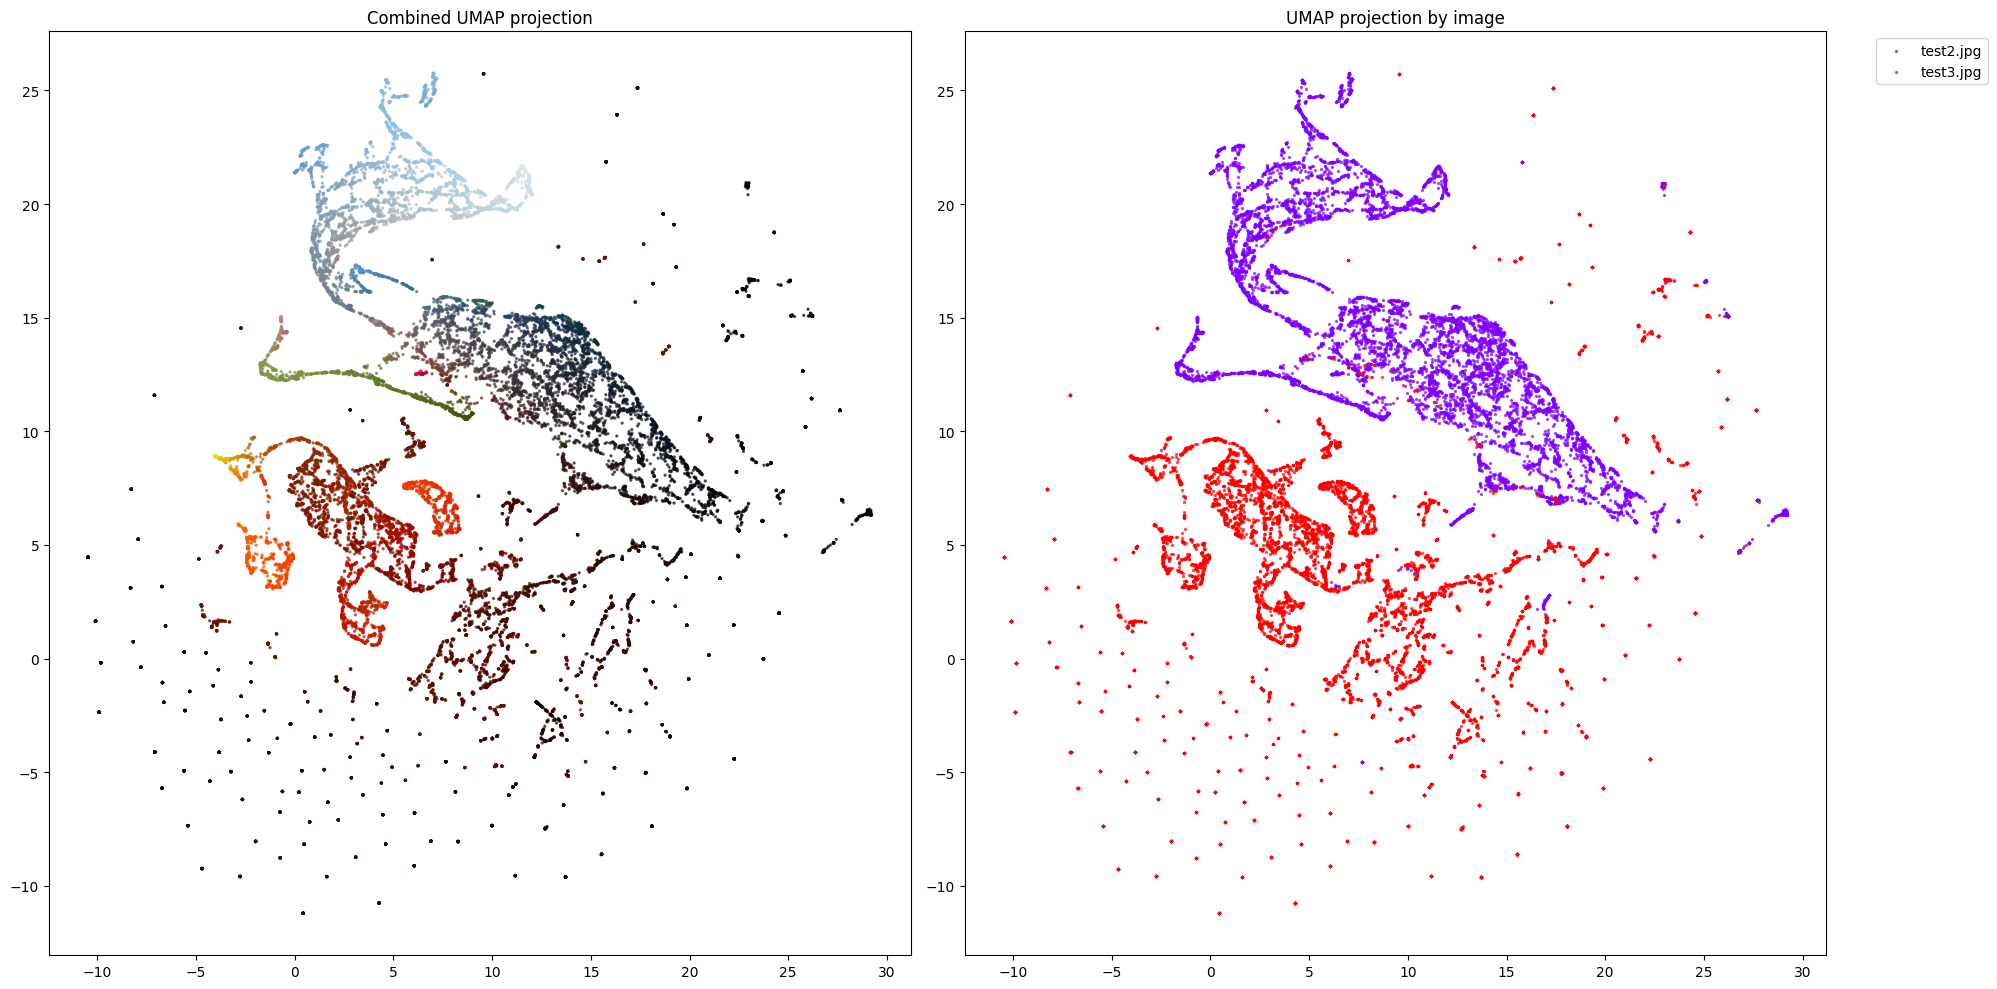


Results saved to 'umap_results.npz'


In [47]:
# Run this all in one cell
!pip install umap-learn pillow numpy matplotlib scikit-learn tqdm

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import umap
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm
import time
from pathlib import Path
import os

class ImageUMAPAnalyzer:
    def __init__(self, max_pixels=10000):
        self.max_pixels = max_pixels
        self.scaler = StandardScaler()
    
    def process_images(self, image_paths):
        """Process multiple images and combine their pixels"""
        if not image_paths:
            raise ValueError("No image paths provided")
            
        all_pixels = []
        image_indices = []
        valid_paths = []
        
        for idx, path in enumerate(image_paths):
            try:
                print(f"\nProcessing {Path(path).name}...")
                if not os.path.exists(path):
                    raise FileNotFoundError(f"Image not found: {path}")
                    
                img = Image.open(path)
                img = img.convert('RGB')
                
                # Original dimensions
                width, height = img.size
                print(f"Original dimensions: {width}x{height} ({width*height} pixels)")
                
                # Downsample if needed
                if width * height > self.max_pixels:
                    scale = np.sqrt(self.max_pixels / (width * height))
                    new_width = int(width * scale)
                    new_height = int(height * scale)
                    img = img.resize((new_width, new_height))
                    print(f"Resized to: {new_width}x{new_height} ({new_width*new_height} pixels)")
                
                pixels = np.array(img)
                reshaped_pixels = pixels.reshape(-1, 3)
                
                all_pixels.append(reshaped_pixels)
                image_indices.extend([len(valid_paths)] * len(reshaped_pixels))
                valid_paths.append(path)
                
            except Exception as e:
                print(f"Error processing {path}: {str(e)}")
                continue
        
        if not all_pixels:
            raise ValueError("No valid images were processed")
            
        combined_pixels = np.vstack(all_pixels)
        return combined_pixels, np.array(image_indices), valid_paths

    def make_umap(self, pixels, n_neighbors=15, min_dist=0.1, random_state=42):
        """Create UMAP embedding with progress updates"""
        print("\nCreating UMAP embedding...")
        
        # 1. Scaling
        print("1/3 Scaling RGB values...")
        scaled_pixels = self.scaler.fit_transform(pixels)
        print("   Scaling complete")
        
        # 2. UMAP
        print("2/3 Creating UMAP reducer...")
        reducer = umap.UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            random_state=random_state,
            verbose=True
        )
        
        # 3. Fitting
        print("3/3 Fitting UMAP...")
        start_time = time.time()
        embedding = reducer.fit_transform(scaled_pixels)
        end_time = time.time()
        
        print(f"\nUMAP processing completed in {end_time - start_time:.2f} seconds")
        return embedding

    def plot_results(self, embedding, pixels, image_indices, image_paths):
        """Plot UMAP results for multiple images"""
        plt.figure(figsize=(20, 10))
        
        # Plot 1: Combined visualization
        plt.subplot(1, 2, 1)
        plt.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c=pixels/255,
            s=2,
            alpha=0.6
        )
        plt.title("Combined UMAP projection")
        
        # Plot 2: Separated by image
        plt.subplot(1, 2, 2)
        unique_indices = np.unique(image_indices)
        colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_indices)))
        
        for idx, color in zip(unique_indices, colors):
            mask = image_indices == idx
            plt.scatter(
                embedding[mask, 0],
                embedding[mask, 1],
                c=[color],
                s=2,
                alpha=0.6,
                label=Path(image_paths[idx]).name
            )
        
        plt.title("UMAP projection by image")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

# Example usage:
try:
    # Initialize analyzer
    analyzer = ImageUMAPAnalyzer(max_pixels=10000)

    # List of image paths
    image_paths = [
        "test2.jpg",
        "test3.jpg"
    ]

    # Process all images
    pixels, image_indices, valid_paths = analyzer.process_images(image_paths)

    # Create UMAP embedding
    embedding = analyzer.make_umap(pixels)  # Note: changed from create_umap to make_umap

    # Visualize results
    analyzer.plot_results(embedding, pixels, image_indices, valid_paths)

    # Optional: Save the embeddings
    np.savez('umap_results.npz', 
             embedding=embedding, 
             pixels=pixels, 
             image_indices=image_indices)
    print("\nResults saved to 'umap_results.npz'")

except Exception as e:
    print(f"An error occurred: {str(e)}")

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import umap
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm
import time
from pathlib import Path
import os


In [40]:
class ImageUMAPAnalyzer:
    def __init__(self, max_pixels=10000):
        self.max_pixels = max_pixels
        self.scaler = StandardScaler()
    
    def process_images(self, image_paths):
        """Process multiple images and combine their pixels"""
        if not image_paths:
            raise ValueError("No image paths provided")
            
        all_pixels = []
        image_indices = []
        valid_paths = []
        
        for idx, path in enumerate(image_paths):
            try:
                print(f"\nProcessing {Path(path).name}...")
                if not os.path.exists(path):
                    raise FileNotFoundError(f"Image not found: {path}")
                    
                img = Image.open(path)
                img = img.convert('RGB')
                
                # Original dimensions
                width, height = img.size
                print(f"Original dimensions: {width}x{height} ({width*height} pixels)")
                
                # Downsample if needed
                if width * height > self.max_pixels:
                    scale = np.sqrt(self.max_pixels / (width * height))
                    new_width = int(width * scale)
                    new_height = int(height * scale)
                    img = img.resize((new_width, new_height))
                    print(f"Resized to: {new_width}x{new_height} ({new_width*new_height} pixels)")
                
                pixels = np.array(img)
                reshaped_pixels = pixels.reshape(-1, 3)
                
                all_pixels.append(reshaped_pixels)
                image_indices.extend([len(valid_paths)] * len(reshaped_pixels))
                valid_paths.append(path)
                
            except Exception as e:
                print(f"Error processing {path}: {str(e)}")
                continue
        
        if not all_pixels:
            raise ValueError("No valid images were processed")
            
        combined_pixels = np.vstack(all_pixels)
        return combined_pixels, np.array(image_indices), valid_paths



In [41]:
def create_umap(self, pixels, n_neighbors=15, min_dist=0.1, random_state=42):
        """Create UMAP embedding with progress updates"""
        print("\nCreating UMAP embedding...")
        
        # 1. Scaling
        print("1/3 Scaling RGB values...")
        scaled_pixels = self.scaler.fit_transform(pixels)
        print("   Scaling complete")
        
        # 2. UMAP
        print("2/3 Creating UMAP reducer...")
        reducer = umap.UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            random_state=random_state,
            verbose=True
        )
        
        # 3. Fitting
        print("3/3 Fitting UMAP...")
        start_time = time.time()
        embedding = reducer.fit_transform(scaled_pixels)
        end_time = time.time()
        
        print(f"\nUMAP processing completed in {end_time - start_time:.2f} seconds")
        return embedding

In [42]:
def plot_results(self, embedding, pixels, image_indices, image_paths):
        """Plot UMAP results for multiple images"""
        plt.figure(figsize=(20, 10))
        
        # Plot 1: Combined visualization
        plt.subplot(1, 2, 1)
        plt.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c=pixels/255,
            s=2,
            alpha=0.6
        )
        plt.title("Combined UMAP projection")
        
        # Plot 2: Separated by image
        plt.subplot(1, 2, 2)
        unique_indices = np.unique(image_indices)
        colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_indices)))
        
        for idx, color in zip(unique_indices, colors):
            mask = image_indices == idx
            plt.scatter(
                embedding[mask, 0],
                embedding[mask, 1],
                c=[color],
                s=2,
                alpha=0.6,
                label=Path(image_paths[idx]).name
            )
        
        plt.title("UMAP projection by image")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

In [43]:
# Example usage:
try:
    # Initialize analyzer
    analyzer = ImageUMAPAnalyzer(max_pixels=10000)

    # List of image paths
    image_paths = [
        "test2.jpg",
        "test3.jpg"
    ]

    # Process all images
    pixels, image_indices, valid_paths = analyzer.process_images(image_paths)

    # Create UMAP embedding
    embedding = analyzer.create_umap(pixels)

    # Visualize results
    analyzer.plot_results(embedding, pixels, image_indices, valid_paths)

    # Optional: Save the embeddings
    np.savez('umap_results.npz', 
             embedding=embedding, 
             pixels=pixels, 
             image_indices=image_indices)
    print("\nResults saved to 'umap_results.npz'")

except Exception as e:
    print(f"An error occurred: {str(e)}")


Processing test2.jpg...
Original dimensions: 6000x4000 (24000000 pixels)
Resized to: 122x81 (9882 pixels)

Processing test3.jpg...
Original dimensions: 300x200 (60000 pixels)
Resized to: 122x81 (9882 pixels)
An error occurred: 'ImageUMAPAnalyzer' object has no attribute 'create_umap'
